<a href="https://colab.research.google.com/github/giggletang/Android_ChatGPT/blob/main/Copy_of_CSC8851_S2026_HW1_%3CYourName%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#CSC 8851 – Deep Learning - Spring 2026 Homework1
#Basic Settings

import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os, math, random, time
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Set device to A100 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Reproducibility
seed = 36
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

OUT_DIR = "homework1"
os.makedirs(OUT_DIR, exist_ok=True)


device: cuda


In [ ]:
# dataset load, MNIST, test data is used for validation

BATCH_SIZE = 128

tfm = transforms.ToTensor()

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
val_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# quick sanity
x, y = next(iter(train_loader))
print(x.shape, y.shape, x.min().item(), x.max().item())


torch.Size([128, 1, 28, 28]) torch.Size([128]) 0.0 1.0


In [ ]:
# model architecture, as homework1 suggested

class CondBetaVAE(nn.Module):
    def __init__(self, z_dim=2, n_classes=10, emb_dim=16):
        super().__init__()
        self.z_dim = z_dim
        self.n_classes = n_classes
        self.emb_dim = emb_dim

        # label embedding
        self.emb = nn.Embedding(n_classes, emb_dim)

        # Encoder CNN
        self.enc_conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.enc_fc = nn.Linear(128*7*7 + emb_dim, 256)
        self.enc_mu = nn.Linear(256, z_dim)
        self.enc_logvar = nn.Linear(256, z_dim)

        # Decoder MLP + deconv
        self.dec_fc1 = nn.Linear(z_dim + emb_dim, 256)
        self.dec_fc2 = nn.Linear(256, 128*7*7)
        self.dec_deconv1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.dec_deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.dec_out = nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1)
        self.apply(self._init_weights)

        # last layer init to 0
        nn.init.constant_(self.dec_out.weight, 0.0)
        if self.dec_out.bias is not None:
            nn.init.constant_(self.dec_out.bias, 0.0)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
            nn.init.normal_(m.weight, mean=0.0, std=1e-2)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)

    def encode(self, x, y):
        h = F.relu(self.enc_conv1(x))
        h = F.relu(self.enc_conv2(h))
        h = F.relu(self.enc_conv3(h))
        h = h.view(h.size(0), -1)  # 128*7*7

        y_emb = self.emb(y)
        h = torch.cat([h, y_emb], dim=1)  # 128*7*7+16
        h = F.relu(self.enc_fc(h))        # 256
        mu = self.enc_mu(h)
        logvar = self.enc_logvar(h)
        logvar = torch.clamp(logvar, -8.0, 8.0)
        return mu, logvar

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z, y):
        y_emb = self.emb(y)
        h = torch.cat([z, y_emb], dim=1)  # 18
        h = F.relu(self.dec_fc1(h))       # 256
        h = F.relu(self.dec_fc2(h))       # 128*7*7
        h = h.view(h.size(0), 128, 7, 7)
        h = F.relu(self.dec_deconv1(h))   # 64,14,14
        h = F.relu(self.dec_deconv2(h))   # 32,28,28
        logits = self.dec_out(h)          # 1,28,28
        return logits

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparam(mu, logvar)
        logits = self.decode(z, y)
        return logits, mu, logvar, z


In [ ]:
# Loss with logits

bce_logits = nn.BCEWithLogitsLoss(reduction="sum")  # BCE with logits ×784

def kl_divergence(mu, logvar):
    # KL per sample: 0.5 * sum(mu^2 + exp(logvar) - 1 - logvar)
    return 0.5 * torch.sum(mu**2 + torch.exp(logvar) - 1.0 - logvar, dim=1)

@torch.no_grad()
def evaluate(model, loader, beta_eff):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits, mu, logvar, z = model(x, y)
        recon = bce_logits(logits, x)
        kl = kl_divergence(mu, logvar).sum()
        loss = recon + beta_eff * kl

        bs = x.size(0)
        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        n += bs

    # report per-sample average
    return {
        "loss": total_loss / n,
        "recon": total_recon / n,
        "kl": total_kl / n
    }

def train_one_epoch(model, loader, optimizer, beta_eff, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    n = 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits, mu, logvar, z = model(x, y)

        recon = bce_logits(logits, x)
        kl = kl_divergence(mu, logvar).sum()
        loss = recon + beta_eff * kl

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        n += bs

    return {
        "loss": total_loss / n,
        "recon": total_recon / n,
        "kl": total_kl / n
    }

def beta_warmup(epoch_idx, warmup_epochs, target_beta):
    if warmup_epochs <= 0:
        return target_beta
    t = (epoch_idx + 1) / warmup_epochs
    return min(target_beta, target_beta * t)

def run_training(beta_target=1.0, epochs=30, warmup_epochs=8, lr=3e-4, wd=1e-4, betas=(0.9, 0.95)):
    model = CondBetaVAE().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=betas, weight_decay=wd)

    history = {
        "train_loss": [], "train_recon": [], "train_kl": [],
        "val_loss": [], "val_recon": [], "val_kl": [],
        "beta_eff": []
    }

    best_val = float("inf")
    best_path = os.path.join(OUT_DIR, f"best_beta{beta_target}.pt")

    for epoch in range(epochs):
        beta_eff = beta_warmup(epoch, warmup_epochs, beta_target)
        history["beta_eff"].append(beta_eff)

        tr = train_one_epoch(model, train_loader, optimizer, beta_eff=beta_eff, grad_clip=1.0)
        va = evaluate(model, val_loader, beta_eff=beta_eff)

        history["train_loss"].append(tr["loss"])
        history["train_recon"].append(tr["recon"])
        history["train_kl"].append(tr["kl"])
        history["val_loss"].append(va["loss"])
        history["val_recon"].append(va["recon"])
        history["val_kl"].append(va["kl"])

        print(f"[beta={beta_target}] epoch {epoch+1:02d}/{epochs} | "
              f"beta_eff={beta_eff:.3f} | "
              f"train L={tr['loss']:.2f} (recon={tr['recon']:.2f}, kl={tr['kl']:.2f}) | "
              f"val L={va['loss']:.2f} (recon={va['recon']:.2f}, kl={va['kl']:.2f})")

        if va["loss"] < best_val:
            best_val = va["loss"]
            torch.save({"model": model.state_dict(), "history": history}, best_path)

    return model, history, best_path


In [ ]:
# figure draw

def plot_curves(history, title, save_path=None):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14,4))

    # total
    plt.subplot(1,3,1)
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"], label="val")
    plt.title(f"{title} - Total Loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()

    # recon
    plt.subplot(1,3,2)
    plt.plot(epochs, history["train_recon"], label="train")
    plt.plot(epochs, history["val_recon"], label="val")
    plt.title(f"{title} - Recon (BCE sum / sample)")
    plt.xlabel("epoch"); plt.ylabel("recon"); plt.legend()

    # KL
    plt.subplot(1,3,3)
    plt.plot(epochs, history["train_kl"], label="train")
    plt.plot(epochs, history["val_kl"], label="val")
    plt.title(f"{title} - KL / sample")
    plt.xlabel("epoch"); plt.ylabel("kl"); plt.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


[beta=1.0] epoch 01/30 | beta_eff=0.125 | train L=203.19 (recon=202.71, kl=3.87) | val L=157.19 (recon=156.12, kl=8.54)


[beta=1.0] epoch 02/30 | beta_eff=0.250 | train L=148.73 (recon=147.18, kl=6.21) | val L=144.76 (recon=143.35, kl=5.65)


[beta=1.0] epoch 03/30 | beta_eff=0.375 | train L=140.82 (recon=138.78, kl=5.43) | val L=137.96 (recon=135.93, kl=5.41)


[beta=1.0] epoch 04/30 | beta_eff=0.500 | train L=137.50 (recon=134.91, kl=5.17) | val L=136.69 (recon=134.15, kl=5.08)


[beta=1.0] epoch 05/30 | beta_eff=0.625 | train L=136.35 (recon=133.25, kl=4.97) | val L=135.50 (recon=132.53, kl=4.75)


...

[beta=1.0] epoch 26/30 | beta_eff=1.000 | train L=130.20 (recon=125.50, kl=4.70) | val L=131.34 (recon=126.91, kl=4.43)


[beta=1.0] epoch 27/30 | beta_eff=1.000 | train L=130.06 (recon=125.37, kl=4.69) | val L=130.75 (recon=126.08, kl=4.67)


[beta=1.0] epoch 28/30 | beta_eff=1.000 | train L=129.96 (recon=125.27, kl=4.69) | val L=130.68 (recon=126.05, kl=4.63)


[beta=1.0] epoch 29/30 | beta_eff=1.000 | train L=129.83 (recon=125.13, kl=4.70) | val L=130.64 (recon=126.21, kl=4.43)


[beta=1.0] epoch 30/30 | beta_eff=1.000 | train L=129.75 (recon=125.04, kl=4.71) | val L=130.71 (recon=126.06, kl=4.65)


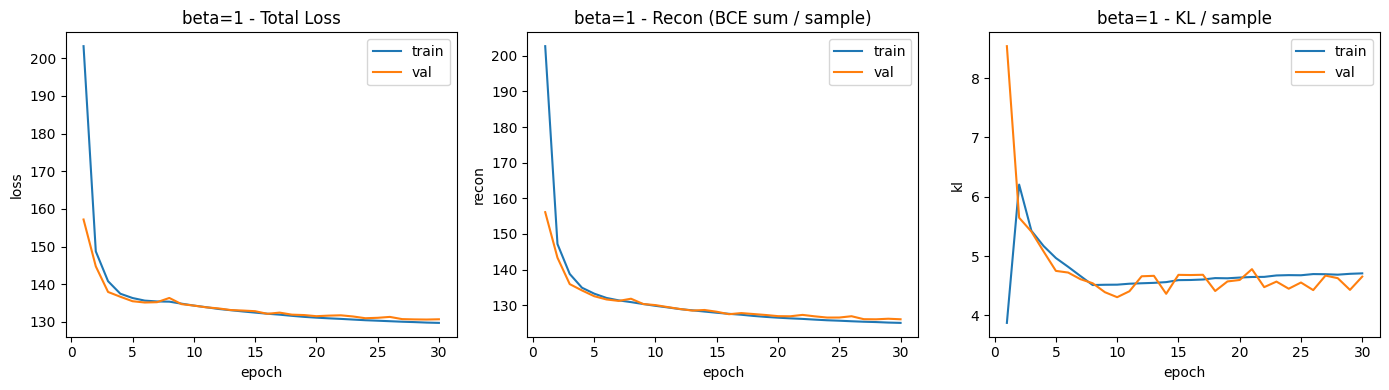

[beta=5.0] epoch 01/30 | beta_eff=0.625 | train L=202.28 (recon=201.13, kl=1.83) | val L=153.37 (recon=150.71, kl=4.26)


[beta=5.0] epoch 02/30 | beta_eff=1.250 | train L=151.41 (recon=146.85, kl=3.65) | val L=147.14 (recon=142.27, kl=3.89)


[beta=5.0] epoch 03/30 | beta_eff=1.875 | train L=145.81 (recon=139.27, kl=3.49) | val L=143.71 (recon=136.92, kl=3.62)


[beta=5.0] epoch 04/30 | beta_eff=2.500 | train L=144.42 (recon=136.18, kl=3.30) | val L=143.37 (recon=134.94, kl=3.37)


[beta=5.0] epoch 05/30 | beta_eff=3.125 | train L=144.62 (recon=134.93, kl=3.10) | val L=143.98 (recon=134.19, kl=3.13)


...

[beta=5.0] epoch 26/30 | beta_eff=5.000 | train L=144.39 (recon=130.51, kl=2.77) | val L=145.02 (recon=131.32, kl=2.74)


[beta=5.0] epoch 27/30 | beta_eff=5.000 | train L=144.27 (recon=130.35, kl=2.78) | val L=144.95 (recon=130.74, kl=2.84)


[beta=5.0] epoch 28/30 | beta_eff=5.000 | train L=144.23 (recon=130.29, kl=2.79) | val L=144.50 (recon=131.14, kl=2.67)


[beta=5.0] epoch 29/30 | beta_eff=5.000 | train L=144.20 (recon=130.20, kl=2.80) | val L=144.32 (recon=130.54, kl=2.76)


[beta=5.0] epoch 30/30 | beta_eff=5.000 | train L=144.09 (recon=130.15, kl=2.79) | val L=144.31 (recon=131.06, kl=2.65)


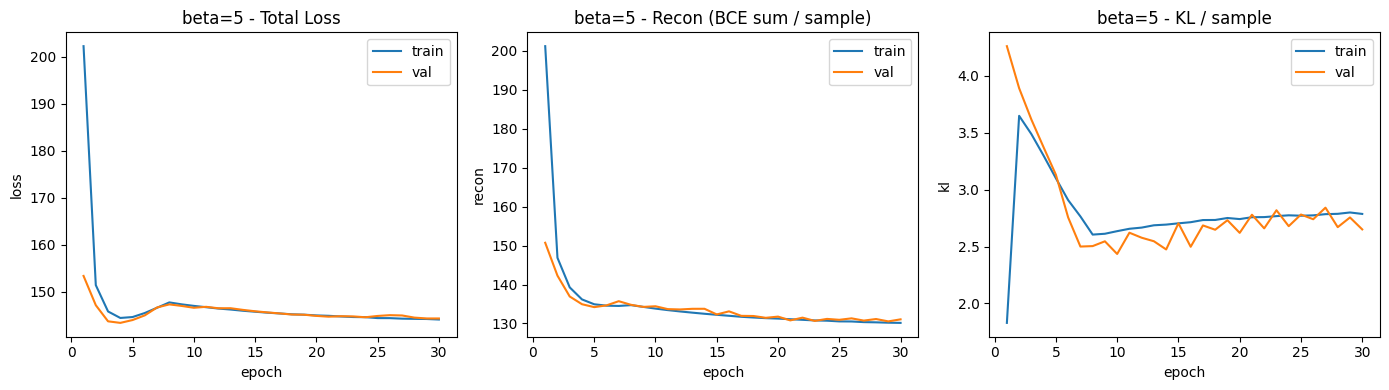

saved best: homework1/best_beta1.0.pt homework1/best_beta5.0.pt


In [ ]:
# Part 1: CVAE + β-VAE Implementation & Training (40 pts)

EPOCHS = 30
WARMUP = 8

# Run β=1
model_b1, hist_b1, best_b1 = run_training(beta_target=1.0, epochs=EPOCHS, warmup_epochs=WARMUP)
plot_curves(hist_b1, "beta=1", save_path=os.path.join(OUT_DIR, "fig1_beta1_curves.png"))

# Run β=5
model_b5, hist_b5, best_b5 = run_training(beta_target=5.0, epochs=EPOCHS, warmup_epochs=WARMUP)
plot_curves(hist_b5, "beta=5", save_path=os.path.join(OUT_DIR, "fig2_beta5_curves.png"))

print("saved best:", best_b1, best_b5)


In [ ]:
# load best checkpoints

def load_best(beta_target):
    path = os.path.join(OUT_DIR, f"best_beta{beta_target}.pt")
    ckpt = torch.load(path, map_location=device)
    model = CondBetaVAE().to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model, ckpt["history"]

best_model_b1, _ = load_best(1.0)
best_model_b5, _ = load_best(5.0)


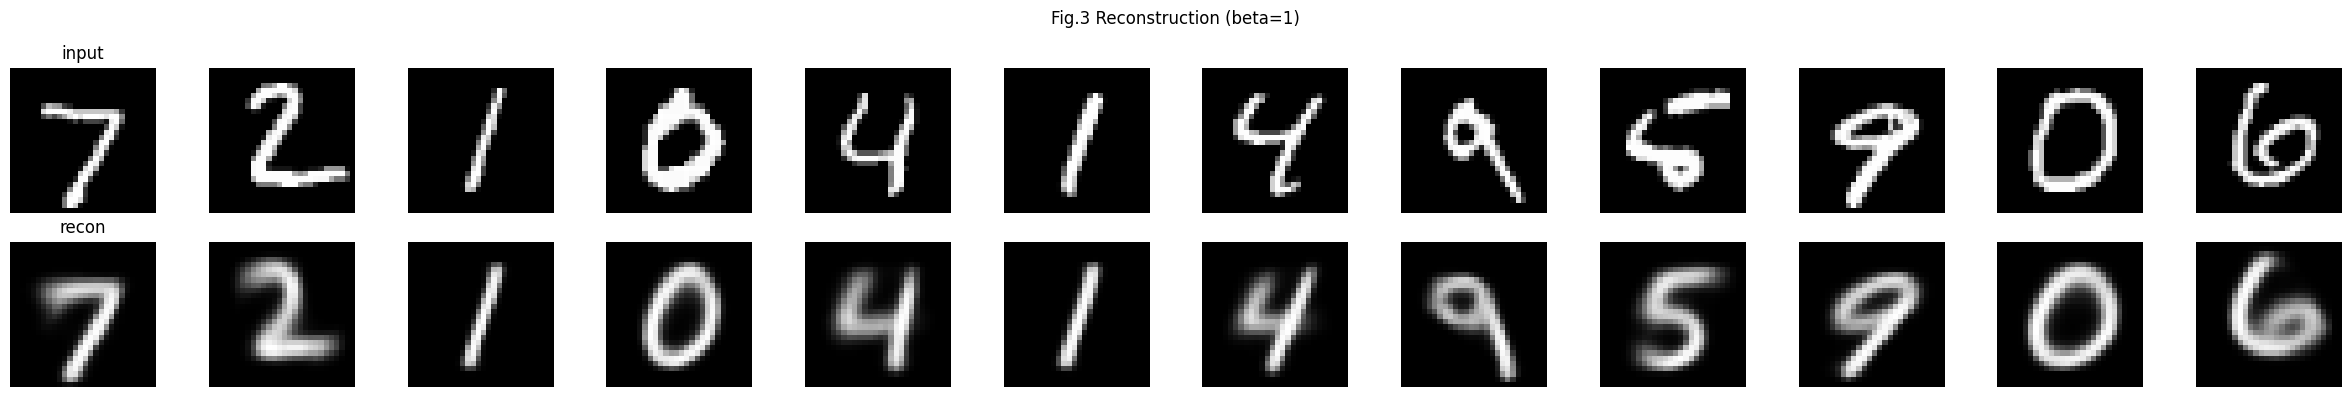

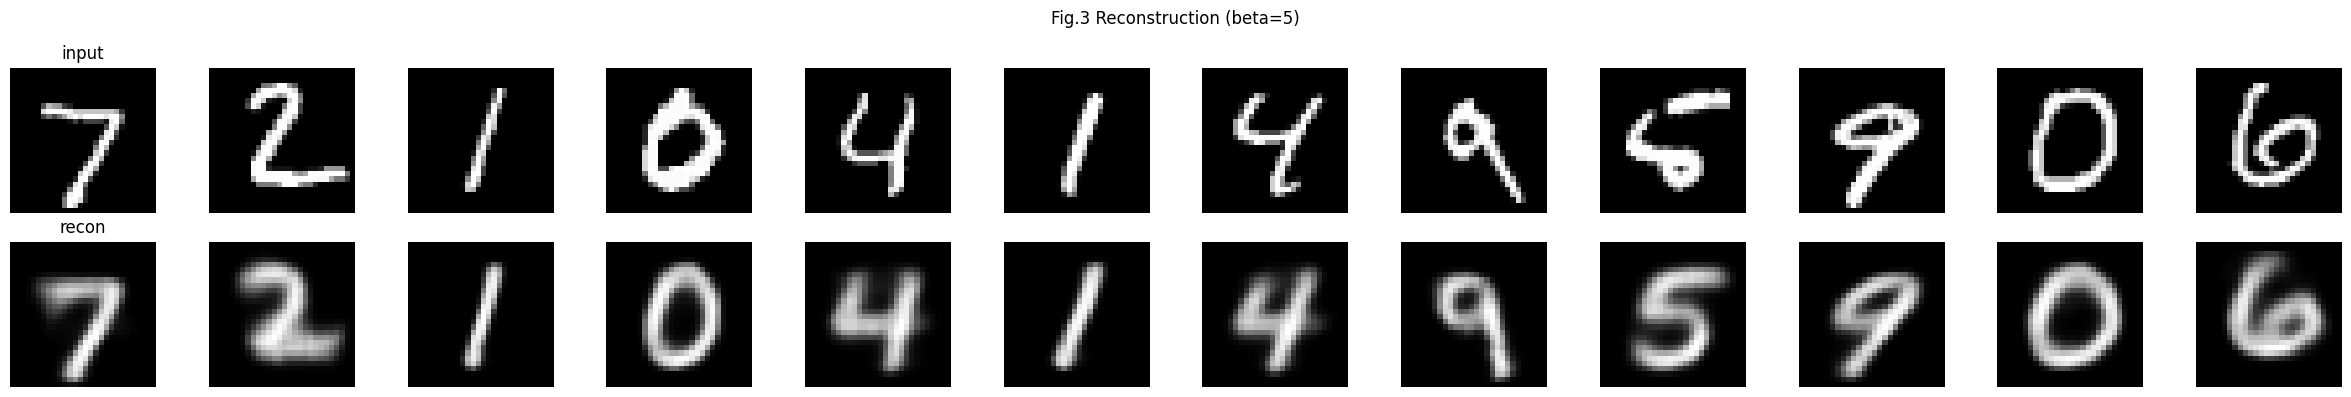

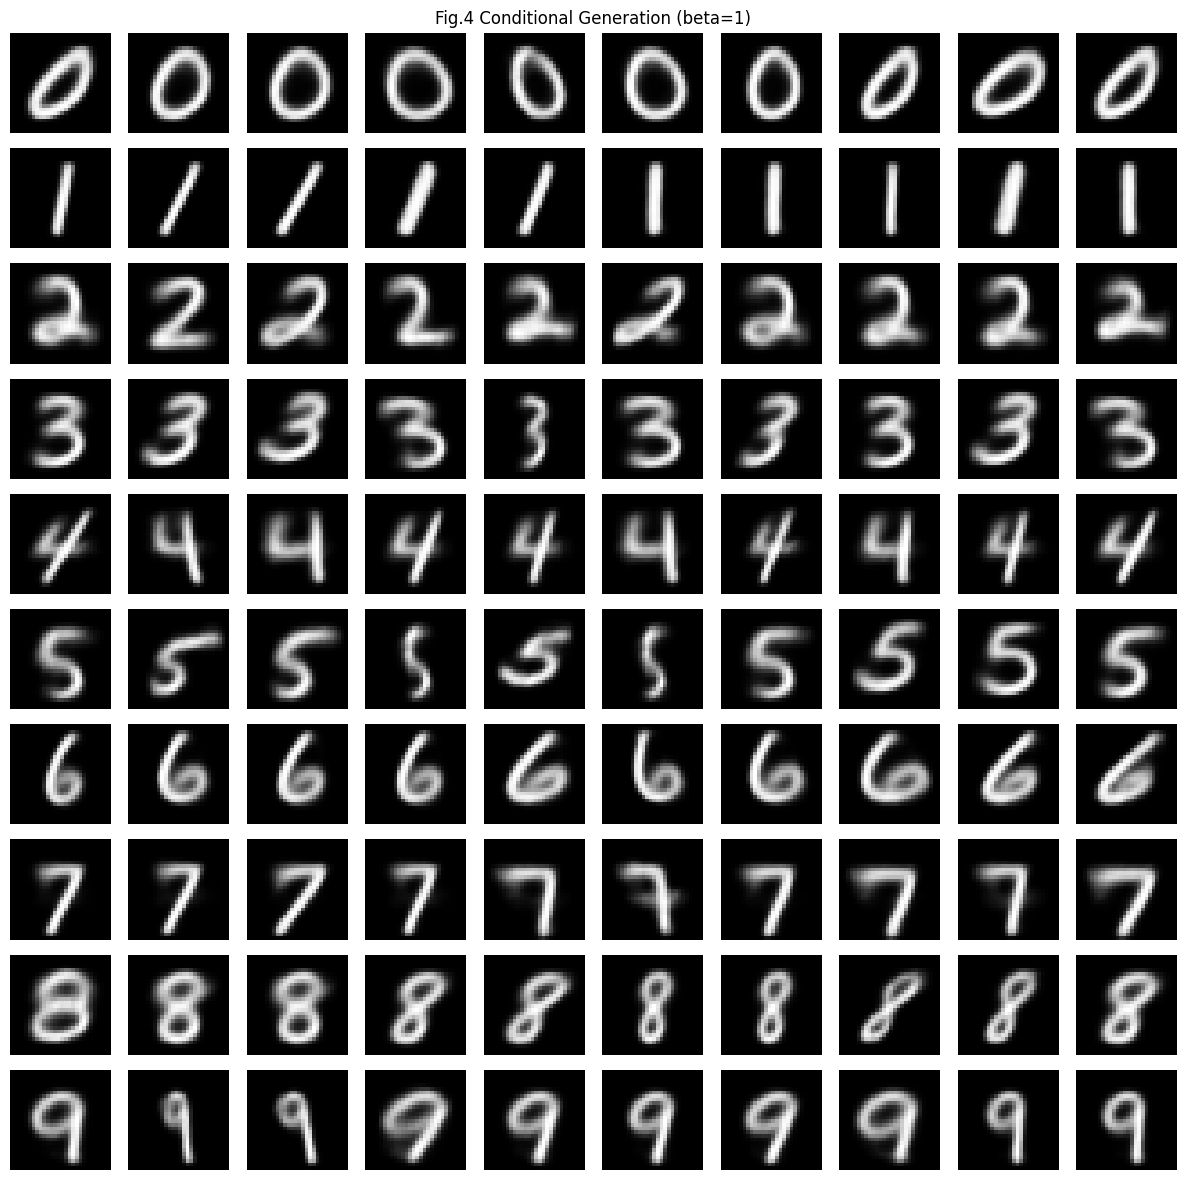

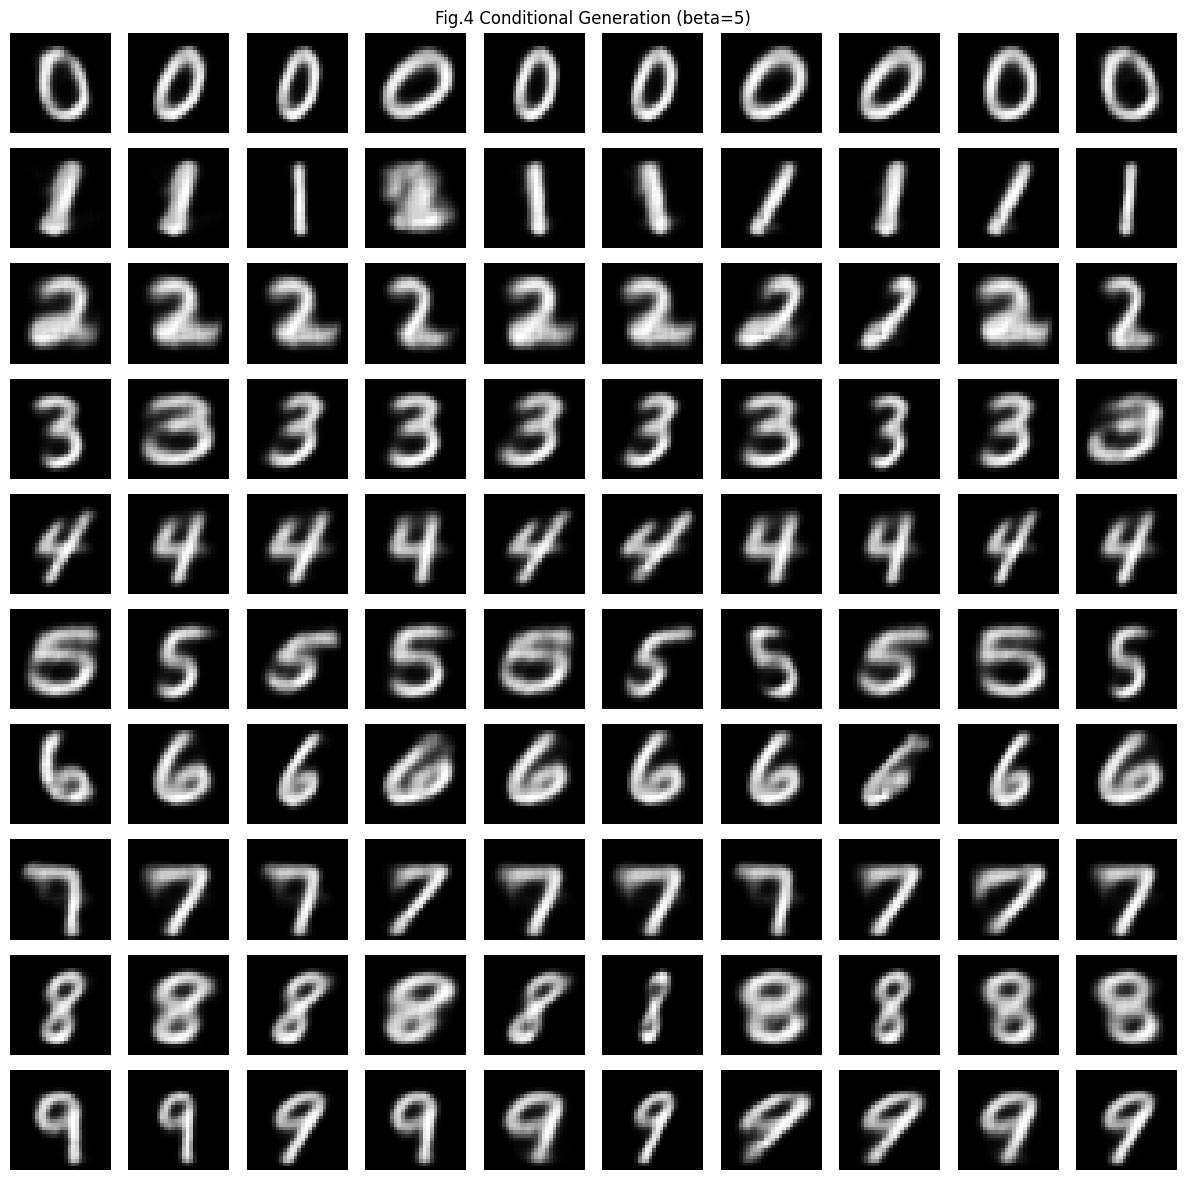

In [ ]:
# Part 2: Reconstructions & Conditional Generation (20 pts)

# Reconstruct test images and compare with inputs
@torch.no_grad()
def show_reconstructions(model, loader, n=12, save_path=None, title="Reconstruction"):
    model.eval()
    x, y = next(iter(loader))
    x = x.to(device)[:n]
    y = y.to(device)[:n]
    logits, mu, logvar, z = model(x, y)
    xhat = torch.sigmoid(logits)

    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(x[i,0].cpu(), cmap="gray")
        plt.axis("off")
        if i == 0: plt.title("input")

        plt.subplot(2, n, n+i+1)
        plt.imshow(xhat[i,0].cpu(), cmap="gray")
        plt.axis("off")
        if i == 0: plt.title("recon")

    plt.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()

show_reconstructions(best_model_b1, val_loader, n=12,
                     save_path=os.path.join(OUT_DIR, "fig3_recon_beta1.png"),
                     title="Fig.3 Reconstruction (beta=1)")

show_reconstructions(best_model_b5, val_loader, n=12,
                     save_path=os.path.join(OUT_DIR, "fig3_recon_beta5.png"),
                     title="Fig.3 Reconstruction (beta=5)")


# Generate digits by sampling from the prior p(z) and conditioning on labels
@torch.no_grad()
def conditional_generation_grid(model, samples_per_class=10, z_std=1.0, save_path=None, title="Conditional Generation"):
    model.eval()
    rows = 10
    cols = samples_per_class
    plt.figure(figsize=(cols*1.2, rows*1.2))

    for d in range(10):
        y = torch.full((cols,), d, dtype=torch.long, device=device)
        z = torch.randn(cols, 2, device=device) * z_std
        logits = model.decode(z, y)
        imgs = torch.sigmoid(logits).cpu()

        for j in range(cols):
            idx = d*cols + j + 1
            plt.subplot(rows, cols, idx)
            plt.imshow(imgs[j,0], cmap="gray")
            plt.axis("off")
            if j == 0:
                plt.ylabel(str(d), rotation=0, labelpad=10, fontsize=12)

    plt.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()

conditional_generation_grid(best_model_b1, samples_per_class=10,
                            save_path=os.path.join(OUT_DIR, "fig4_gen_beta1.png"),
                            title="Fig.4 Conditional Generation (beta=1)")

conditional_generation_grid(best_model_b5, samples_per_class=10,
                            save_path=os.path.join(OUT_DIR, "fig4_gen_beta5.png"),
                            title="Fig.4 Conditional Generation (beta=5)")


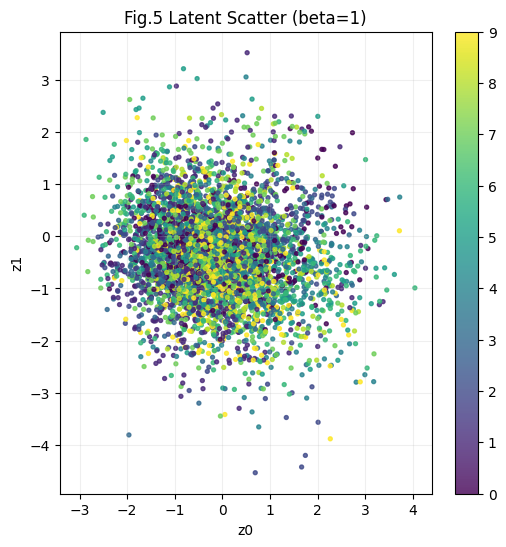

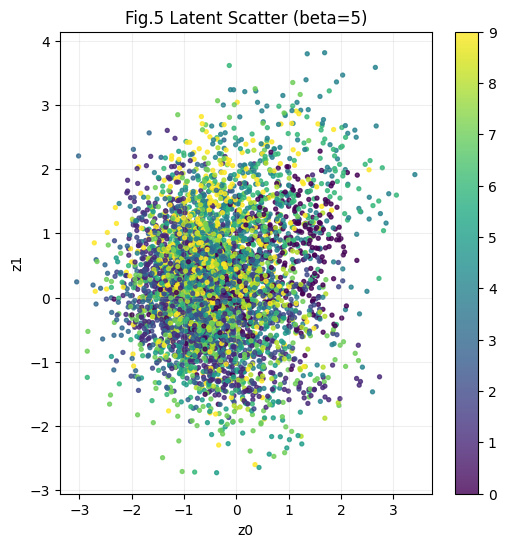

In [ ]:
# Part 3: Latent Space Visualization (10 pts)

@torch.no_grad()
def latent_scatter(model, loader, max_points=5000, save_path=None, title="Latent scatter"):
    model.eval()
    zs = []
    ys = []
    count = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        mu, logvar = model.encode(x, y)
        zs.append(mu.detach().cpu())
        ys.append(y.detach().cpu())
        count += x.size(0)
        if count >= max_points:
            break

    Z = torch.cat(zs, dim=0)[:max_points].numpy()
    Y = torch.cat(ys, dim=0)[:max_points].numpy()

    plt.figure(figsize=(6,6))
    sc = plt.scatter(Z[:,0], Z[:,1], c=Y, s=8, alpha=0.8)
    plt.colorbar(sc, ticks=list(range(10)))
    plt.title(title)
    plt.xlabel("z0"); plt.ylabel("z1")
    plt.grid(True, alpha=0.2)
    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()

latent_scatter(best_model_b1, val_loader, max_points=5000,
               save_path=os.path.join(OUT_DIR, "fig5_scatter_beta1.png"),
               title="Fig.5 Latent Scatter (beta=1)")

latent_scatter(best_model_b5, val_loader, max_points=5000,
               save_path=os.path.join(OUT_DIR, "fig5_scatter_beta5.png"),
               title="Fig.5 Latent Scatter (beta=5)")


β=1: The point clouds of different classes are more mixed and overlapping, and the class boundaries are less distinct.

β=5: The latent space is more regular and closer to a Gaussian structure more concentrated or clustered, but this may sacrifice reconstruction quality, the images are blurrier.

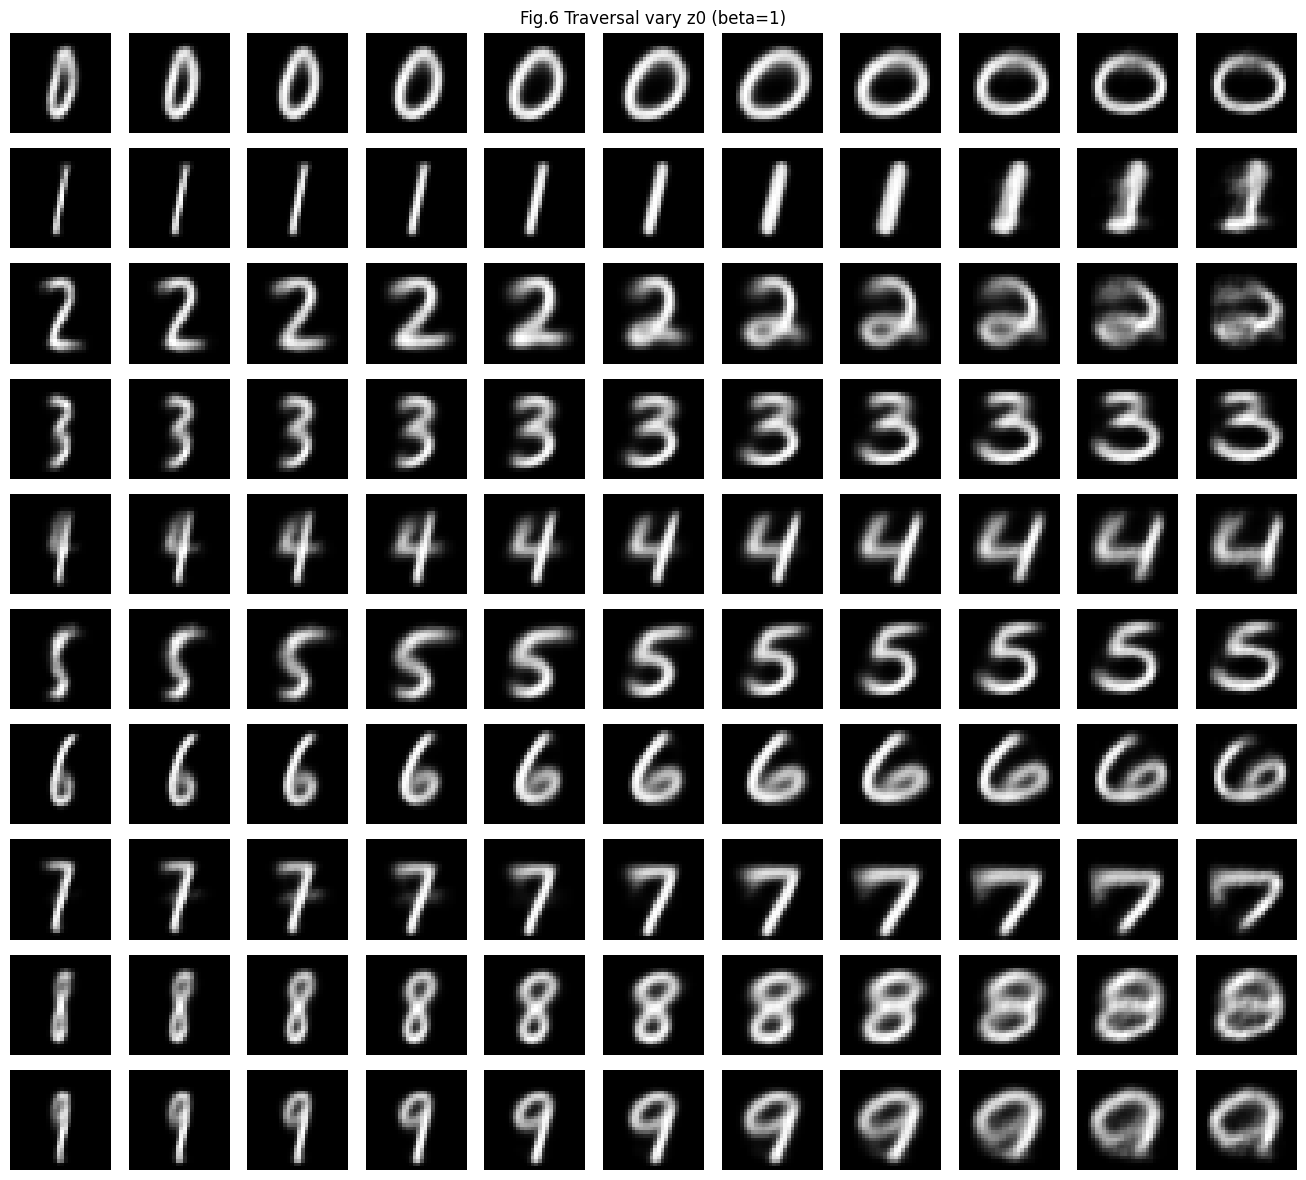

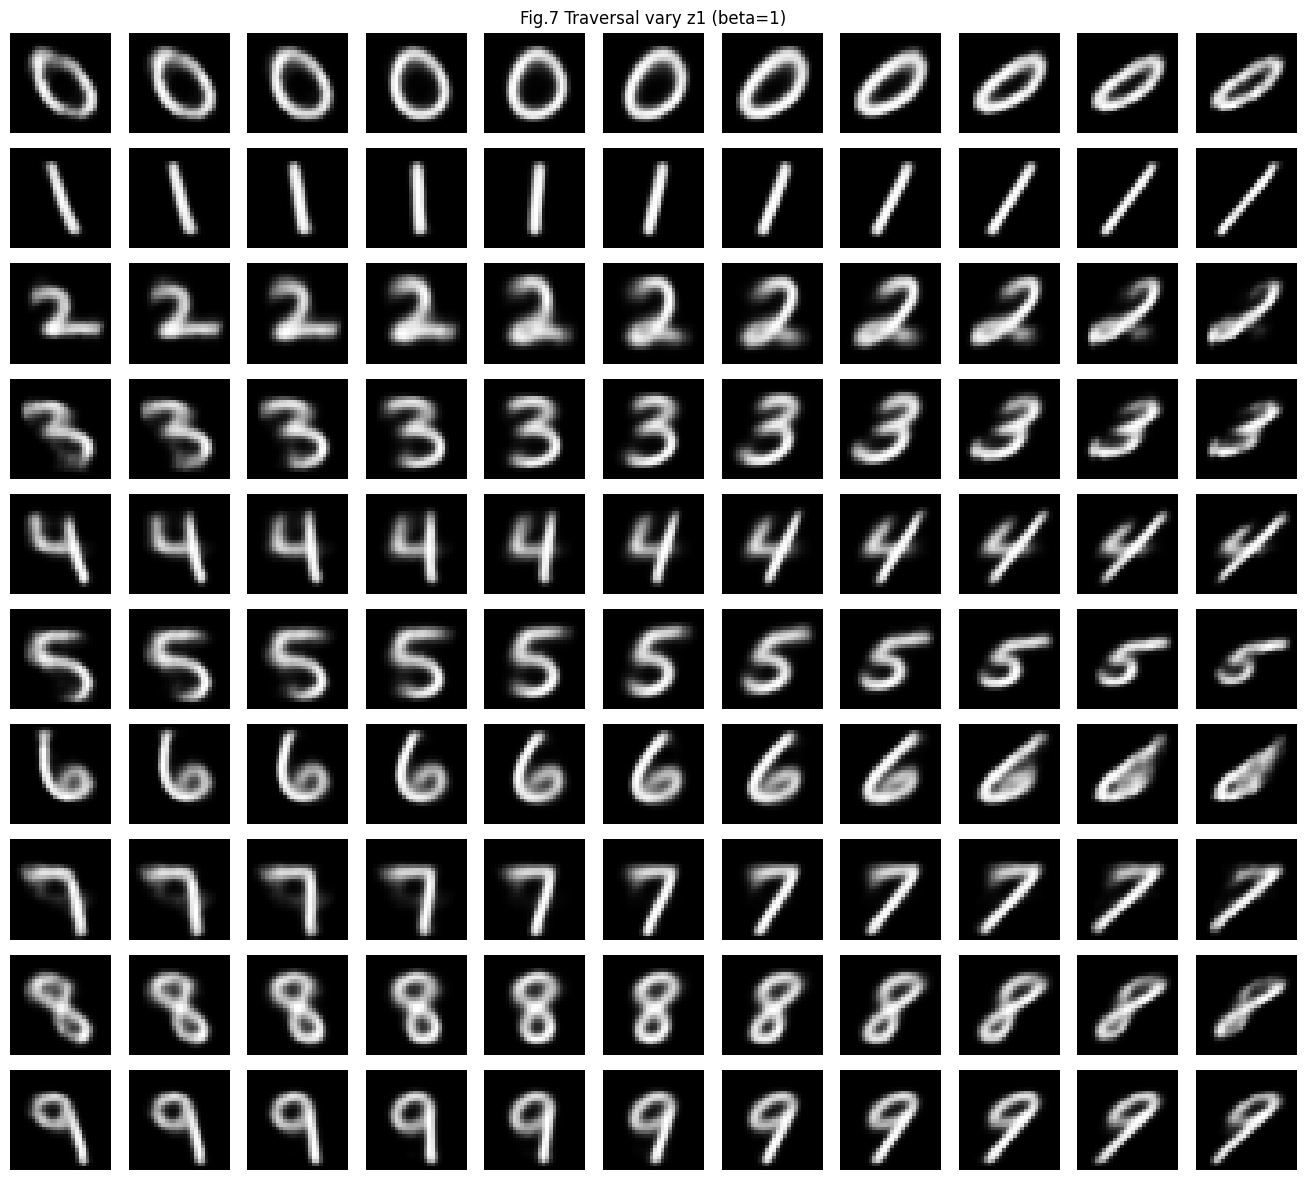

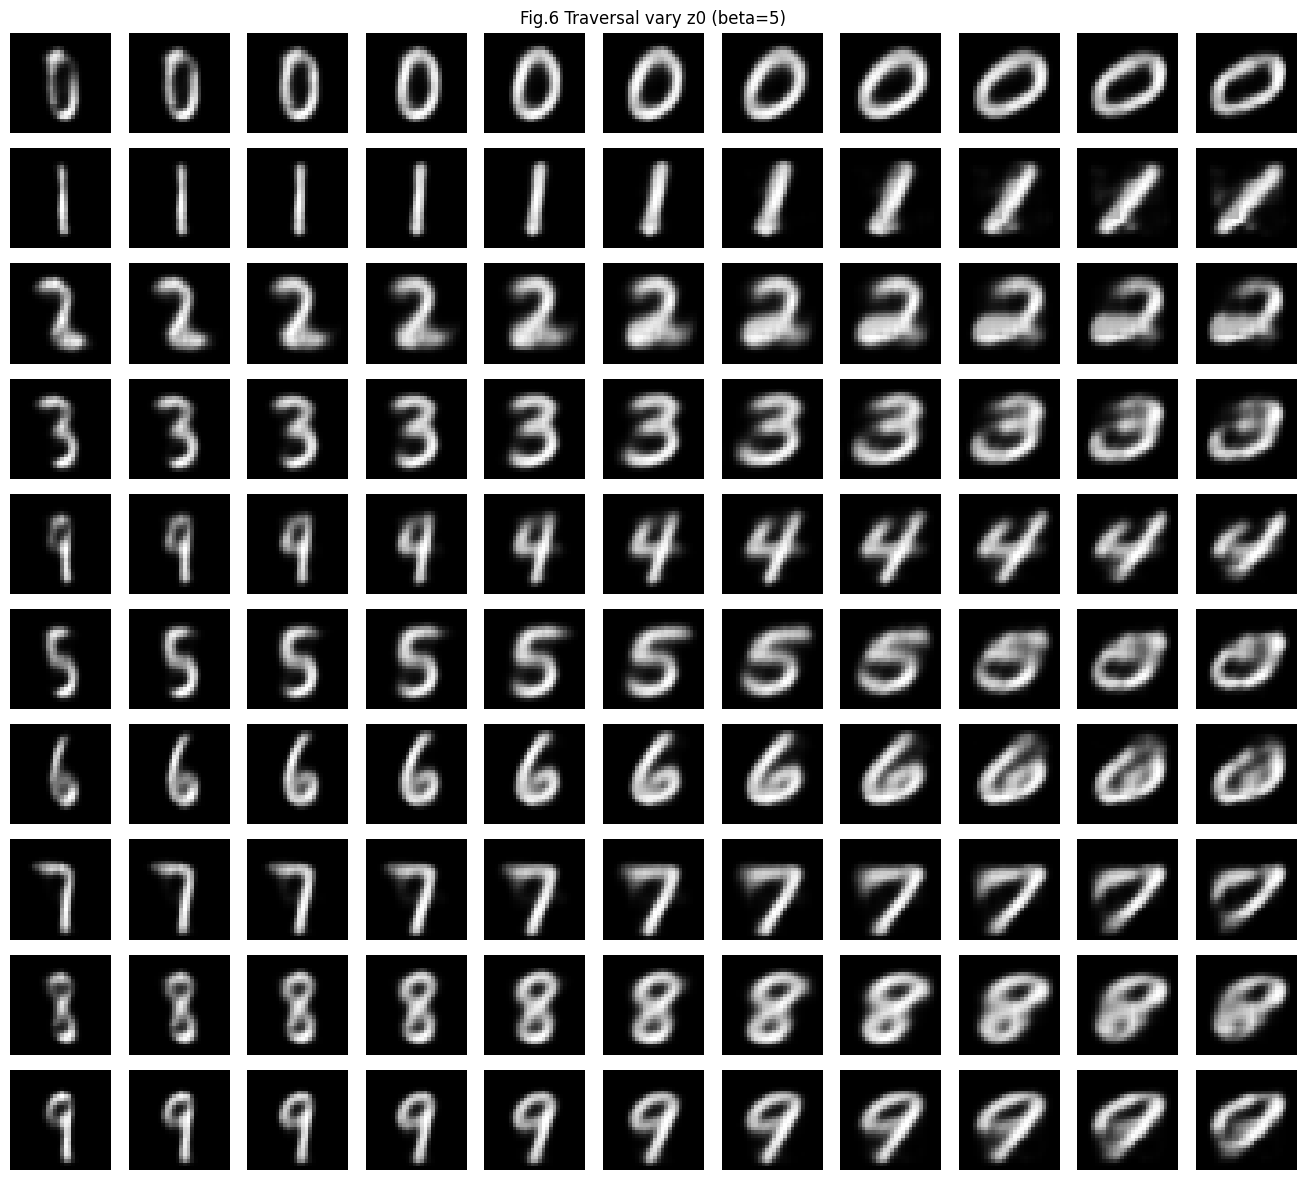

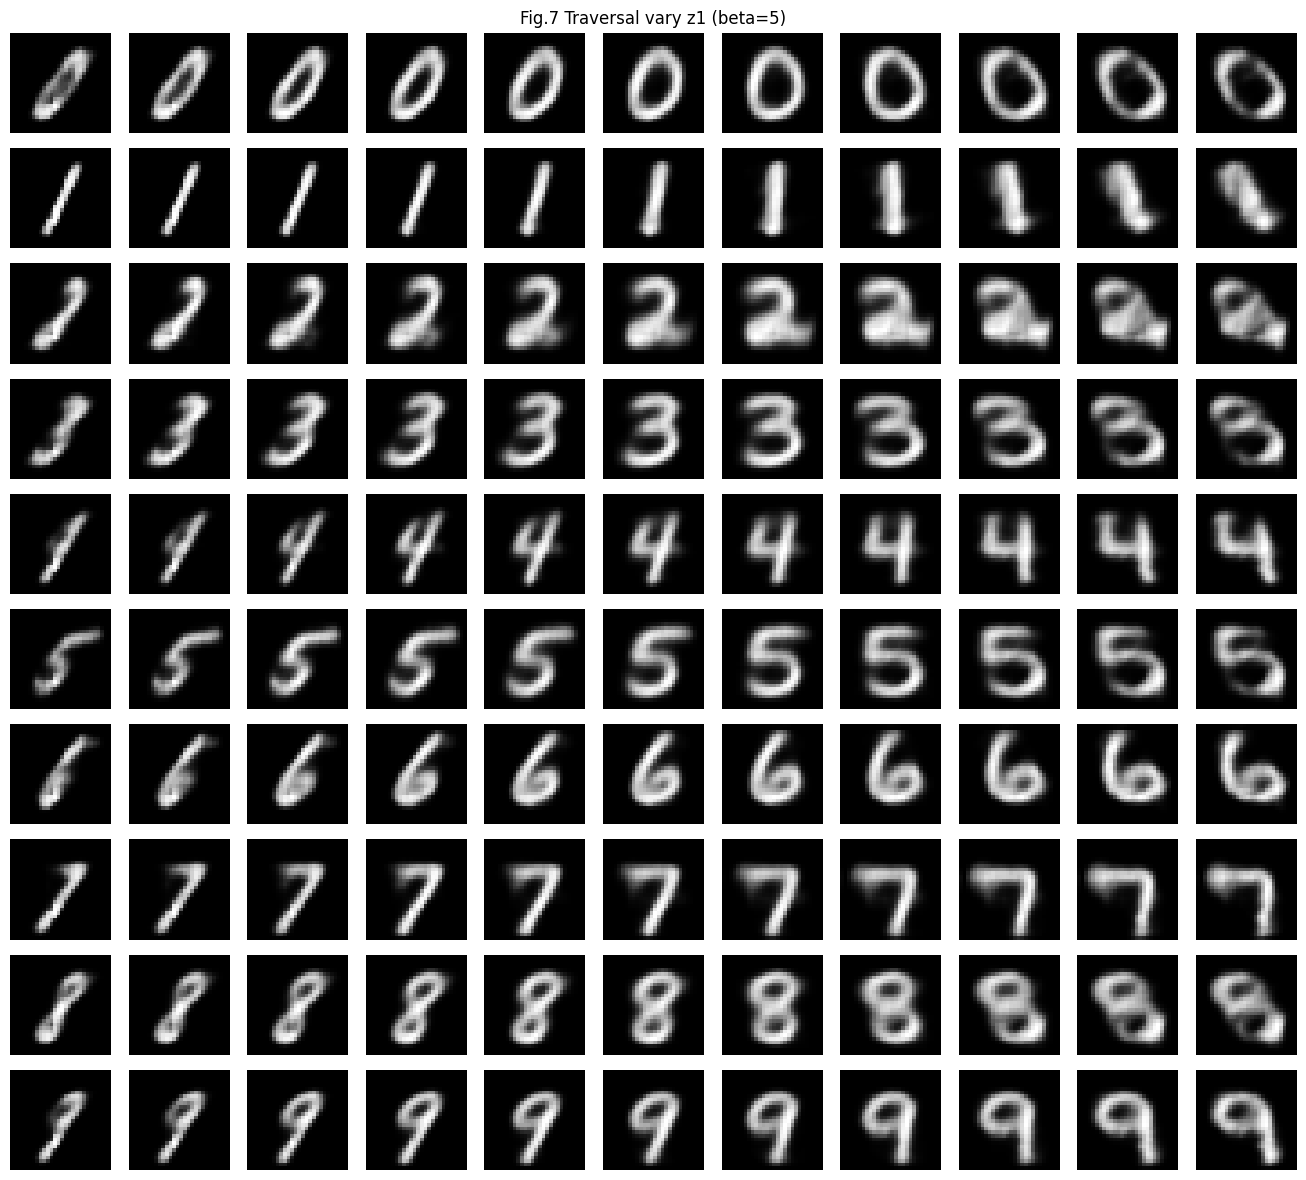

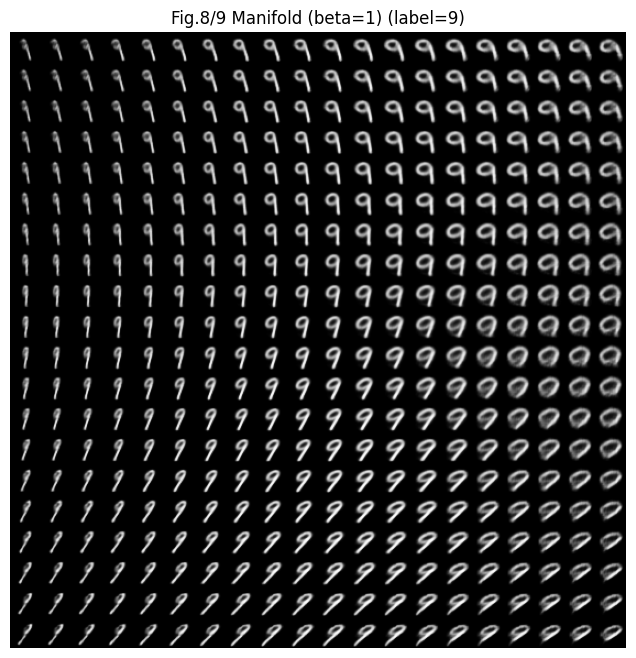

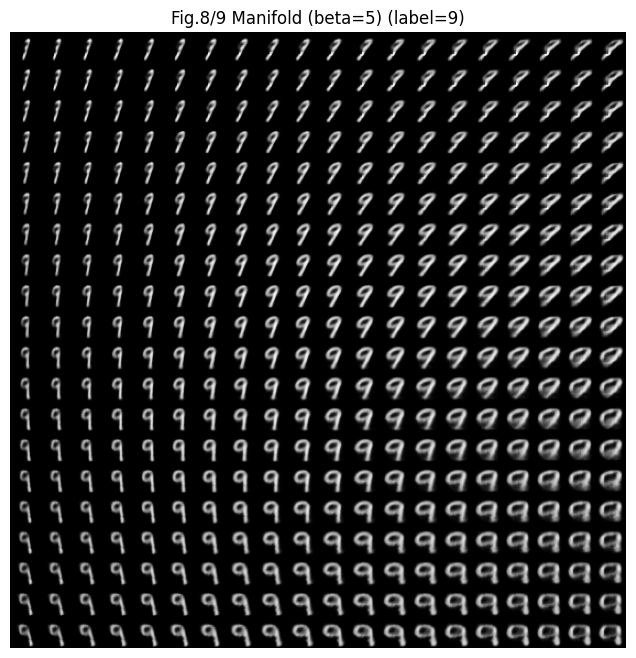

In [ ]:
# Part 4: Latent Traversals & Manifold (30 pts)

#Traversals
@torch.no_grad()
def traversal_fig(model, axis=0, t_min=-3, t_max=3, steps=11, save_path=None, title="Traversal"):
    model.eval()
    ts = torch.linspace(t_min, t_max, steps, device=device)
    rows, cols = 10, steps
    plt.figure(figsize=(cols*1.2, rows*1.2))

    for d in range(10):
        y = torch.full((steps,), d, dtype=torch.long, device=device)
        z = torch.zeros(steps, 2, device=device)
        z[:, axis] = ts
        logits = model.decode(z, y)
        imgs = torch.sigmoid(logits).cpu()

        for j in range(steps):
            idx = d*cols + j + 1
            plt.subplot(rows, cols, idx)
            plt.imshow(imgs[j,0], cmap="gray")
            plt.axis("off")
            if j == 0:
                plt.ylabel(str(d), rotation=0, labelpad=10, fontsize=12)

    plt.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()

# beta=1
traversal_fig(best_model_b1, axis=0, steps=11,
              save_path=os.path.join(OUT_DIR, "fig6_traversal_z0_beta1.png"),
              title="Fig.6 Traversal vary z0 (beta=1)")
traversal_fig(best_model_b1, axis=1, steps=11,
              save_path=os.path.join(OUT_DIR, "fig7_traversal_z1_beta1.png"),
              title="Fig.7 Traversal vary z1 (beta=1)")

# beta=5
traversal_fig(best_model_b5, axis=0, steps=11,
              save_path=os.path.join(OUT_DIR, "fig6_traversal_z0_beta5.png"),
              title="Fig.6 Traversal vary z0 (beta=5)")
traversal_fig(best_model_b5, axis=1, steps=11,
              save_path=os.path.join(OUT_DIR, "fig7_traversal_z1_beta5.png"),
              title="Fig.7 Traversal vary z1 (beta=5)")


# Manifold
@torch.no_grad()
def manifold_fig(model, digit=9, grid=20, z_min=-3, z_max=3, save_path=None, title="Manifold"):
    model.eval()
    zs = torch.linspace(z_min, z_max, grid, device=device)

    # grid x grid images (28x28)
    canvas = torch.zeros((grid*28, grid*28))

    for i, z1 in enumerate(zs):
        for j, z0 in enumerate(zs):
            z = torch.tensor([[z0.item(), z1.item()]], device=device)
            y = torch.tensor([digit], dtype=torch.long, device=device)
            logits = model.decode(z, y)
            img = torch.sigmoid(logits)[0,0].cpu()
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img

    plt.figure(figsize=(8,8))
    plt.imshow(canvas, cmap="gray")
    plt.axis("off")
    plt.title(title + f" (label={digit})")
    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()

manifold_fig(best_model_b1, digit=9, grid=20,
             save_path=os.path.join(OUT_DIR, "fig8_9_manifold_beta1.png"),
             title="Fig.8/9 Manifold (beta=1)")

manifold_fig(best_model_b5, digit=9, grid=20,
             save_path=os.path.join(OUT_DIR, "fig8_9_manifold_beta5.png"),
             title="Fig.8/9 Manifold (beta=5)")
